### Load dependencies

In [1]:
import os
import json
import sympy
import torch
import numpy as np
import pandas as pd
from typing import Dict, List, Callable

# MIRA modeling dependencies
from mira.metamodel import *
from mira.metamodel.ops import stratify
from mira.examples.concepts import susceptible, exposed, infected, recovered
from mira.modeling import Model
from mira.modeling.amr.petrinet import AMRPetriNetModel, template_model_to_petrinet_json
from mira.sources.amr.petrinet import template_model_from_amr_json
from mira.metamodel.io import model_to_json_file, model_from_json_file

# PyCIEMSS dependencies
import pyciemss
import pyciemss.visuals.plots as plots
import pyciemss.visuals.vega as vega
import pyciemss.visuals.trajectories as trajectories
from pyciemss.integration_utils.intervention_builder import (
    param_value_objective,
    start_time_objective,
)

### SIR model

In [7]:
person_units = lambda: Unit(expression=sympy.Symbol('person'))
day_units = lambda: Unit(expression=sympy.Symbol('day'))
per_day_units = lambda: Unit(expression=1/sympy.Symbol('day'))
dimensionless_units = lambda: Unit(expression=sympy.Integer('1'))
per_day_per_person_units = lambda: Unit(expression=1/(sympy.Symbol('day')*sympy.Symbol('person')))

c = {
    'S': Concept(name='S', units=person_units(), identifiers={'ido': '0000514'}),
    'I': Concept(name='I', units=person_units(), identifiers={'ido': '0000511'}),
    'R': Concept(name='R', units=person_units(), identifiers={'ido': '0000592'}),
    'I_deriv': Concept(name='I_deriv', units=person_units(), identifiers={'ido': '0000502'})
}

for concept in c:
    c[concept].name = concept

parameters = {
    'beta': Parameter(name='beta', value=sympy.Float(0.35), units=per_day_units(),
                      distribution=Distribution(type='StandardUniform1',
                                                parameters={'minimum': 0.25,
                                                            'maximum': 0.45})),  # Transmission rate
    'N': Parameter(name='total_population', value=sympy.Float(1001), units=person_units()),  # Total population

    'p1': Parameter(name='p1', value=sympy.Float(1.0), units=per_day_units(),
                     distribution=Distribution(type='StandardUniform1',
                                                parameters={'minimum': 0.9999,
                                                            'maximum': 1.0001})),  # Multiplier
    
    'tr': Parameter(name='tr', value=sympy.Float(14), units=per_day_units(),
                     distribution=Distribution(type='StandardUniform1',
                                                parameters={'minimum': 8.0,
                                                            'maximum': 20.0})),  # Infectious period
}

# S, I, R, beta, N, p1, tr = sympy.symbols('S I R beta N p1 tr')
S, I, R, I_deriv, beta, N, p1, tr = sympy.symbols('S I R I_deriv beta N p1 tr')

initials = {
    "S": Initial(concept=c["S"], expression=1000.0),
    "I": Initial(concept=c["I"], expression=1.0),
    "R": Initial(concept=c["R"], expression=0.0),
    "I_deriv": Initial(concept=c["I_deriv"], expression=0),
}

##### S -> I
si = ControlledConversion(
    subject=c['S'],
    outcome=c['I'],
    controller=c['I'],
    rate_law=beta*p1*S*I / N
)


#### I -> R
ir = NaturalConversion(
    subject=c['I'],
    outcome=c['R'],
    rate_law=(1 / tr)*I
)


#### I_deriv
idpos = GroupedControlledProduction(
    controllers=[c['I'], c['S']],
    outcome=c['I_deriv'],
    rate_law=sympy.Max(0, beta**2*p1**2*S**2*I/N**2 - beta*p1*S*I**2/N**2 - 2*beta*p1*S*I*tr/N + 1/tr**2)
)

#### I_deriv
idneg = GroupedControlledDegradation(
    subject=c['I_deriv'],
    controllers=[c['I'], c['S']],
    rate_law=-sympy.Min(0, beta**2*p1**2*S**2*I/N**2 - beta*p1*S*I**2/N**2 - 2*beta*p1*S*I*tr/N + 1/tr**2)
)

sir_model = TemplateModel(
    templates=[
        si,
        ir,
        idpos,
        idneg
    ],
    parameters=parameters,
    initials=initials,
    time=Time(name='t', units=day_units()),
    observables=[],
    annotations=Annotations(name='SIR')
)

# Save as JSON
with open("SIR_petrinet.json", 'w') as fh:
    json.dump(template_model_to_petrinet_json(sir_model), fh, indent=1)

## Simulate the model with no interventions

,timepoint_id,sample_id,timepoint_unknown,persistent_beta_param,persistent_p1_param,persistent_tr_param,S_state,I_state,R_state,I_deriv_state
0,0,0,0.0,0.429867,0.999911,17.851055,1000.000000,1.000000,0.000000,0.000000
1,1,0,1.0,0.429867,0.999911,17.851055,999.479797,1.452483,0.067908,-18.353161
2,2,0,2.0,0.429867,0.999911,17.851055,998.724304,2.109138,0.166529,-44.992310
3,3,0,3.0,0.429867,0.999911,17.851055,997.628845,3.061457,0.309708,-83.634041
4,4,0,4.0,0.429867,0.999911,17.851055,996.041260,4.441237,0.517476,-139.636124


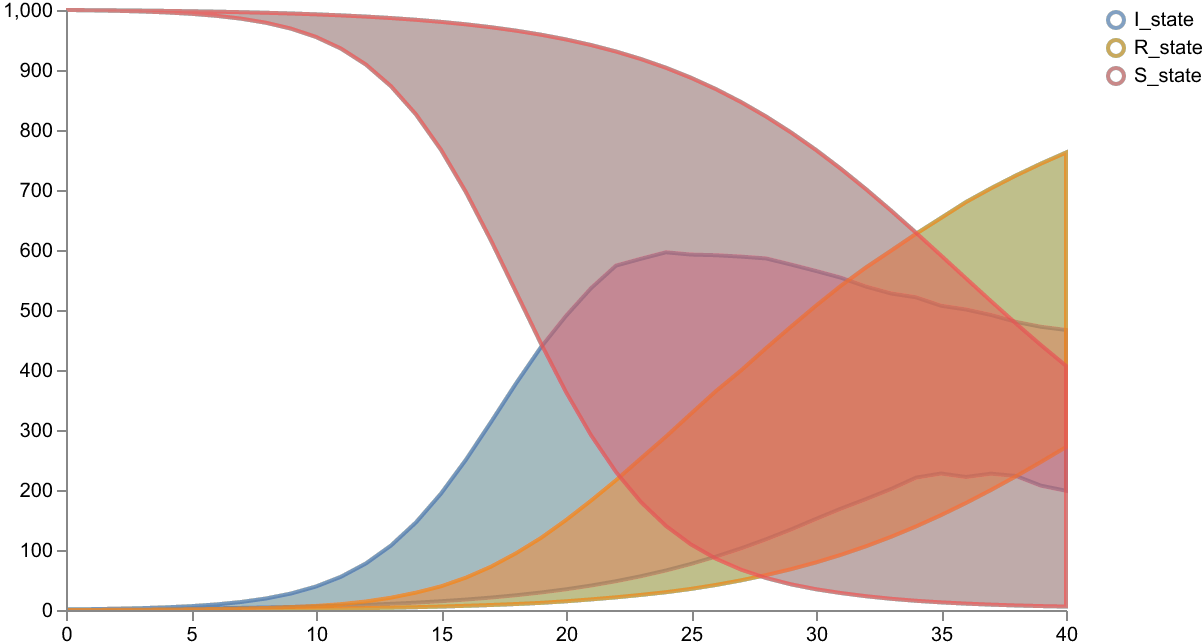

In [10]:
model1 = "SIR_petrinet.json"

start_time = 0.0
end_time = 40.0
logging_step_size = 1.0
num_samples = 100

result1 = pyciemss.sample(model1, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Plot results for all states
schema = plots.trajectories(result1["data"], keep=["S_state", "I_state", "R_state"])
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

,timepoint_id,sample_id,timepoint_unknown,persistent_beta_param,persistent_p1_param,persistent_tr_param,S_state,I_state,R_state,I_deriv_state
0,0,0,0.0,0.366048,0.999963,15.043139,1000.000000,1.000000,0.000000,0.000000
1,1,0,1.0,0.366048,0.999963,15.043139,999.572998,1.348669,0.077489,-12.661832
2,2,0,2.0,0.366048,0.999963,15.043139,998.999512,1.818583,0.181986,-29.730259
3,3,0,3.0,0.366048,0.999963,15.043139,998.225586,2.451624,0.322875,-52.729572
4,4,0,4.0,0.366048,0.999963,15.043139,997.183350,3.303935,0.512776,-83.704216


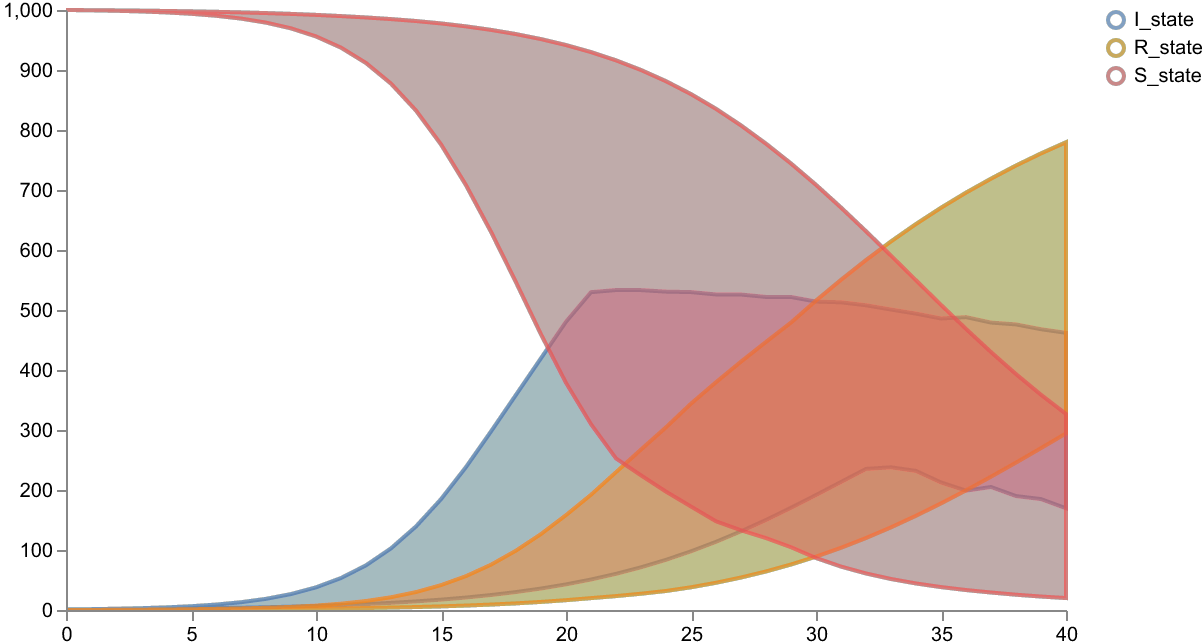

In [12]:
def make_var_threshold_pos(var: str, slope_var: str, threshold: torch.Tensor):
    def var_threshold_pos(time, state):
        # This line might not work, but would be easy to fix
        return state[var] - threshold + (state[slope_var] > 0)
    return var_threshold_pos

def make_var_threshold_neg(var: str, slope_var: str, threshold: torch.Tensor):
    def var_threshold_neg(time, state):
        # This line might not work, but would be easy to fix
        return state[var] - threshold + (state[slope_var] < 0)
    return var_threshold_neg
    
infection_threshold_pos = make_var_threshold_pos("I", "I_deriv", torch.tensor(530.0))
infection_threshold_neg = make_var_threshold_neg("I", "I_deriv", torch.tensor(530.0))
dynamic_parameter_interventions1 = {infection_threshold_pos: {"p1": torch.tensor(0.5)}}

result1 = pyciemss.sample(model1, end_time, logging_step_size, num_samples, start_time=start_time,
                         dynamic_parameter_interventions=dynamic_parameter_interventions1,
                         )
display(result1['data'].head())

# Plot results for all states
schema = plots.trajectories(result1["data"], keep=["S_state", "I_state", "R_state"])
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

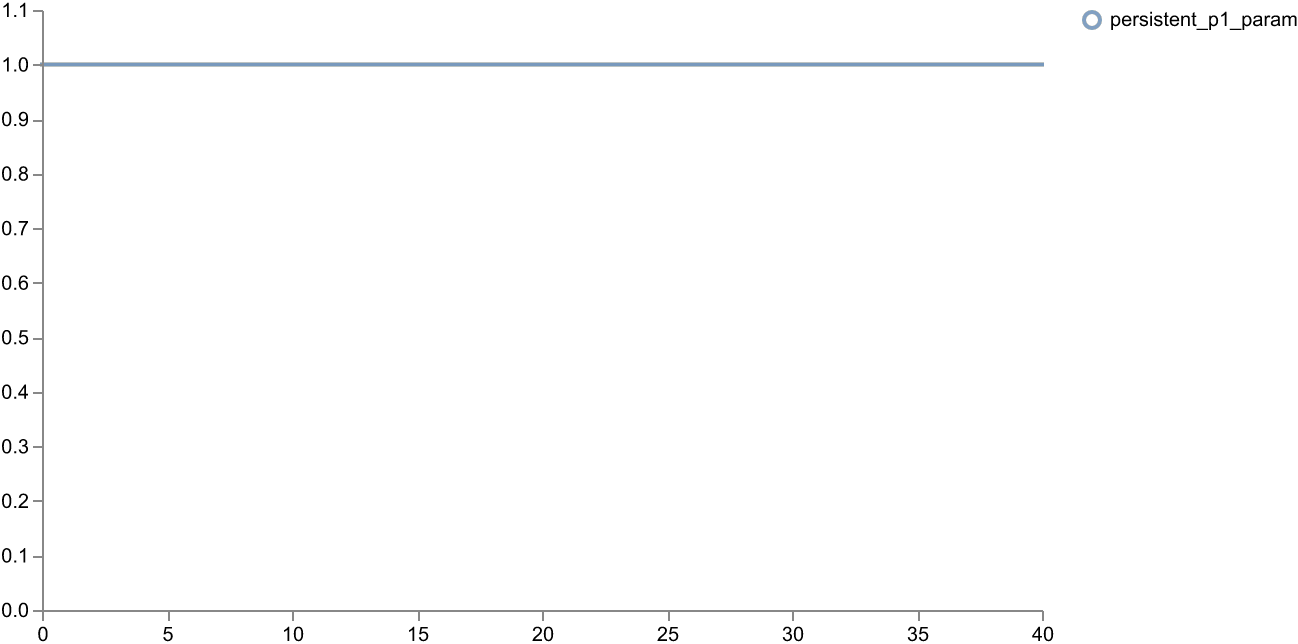

In [14]:
schema = plots.trajectories(pd.DataFrame(result1["data"]), keep="persistent_p1_param")
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)